  0%|          | 0/1 [00:00<?, ?it/s]

Working on mofc 


  0%|          | 0/27 [00:00<?, ?it/s]

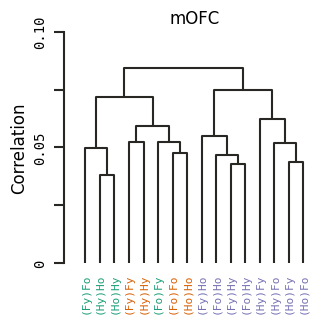

Silhouette Score:  0.38516662413857844


In [1]:
#mofc
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
BLACK = "#282724"
GREY_DARK = "#747473"
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['mofc']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

all_subjects_rdm = np.zeros((len(subject_inds), 4, 16, 16))
average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))

for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
            subject_average_matrices = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices.npy')

            average_all_subjects_rdm[i] = subject_average_matrices


    average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)

    Z = linkage(average_rdm, method='average')

    # 绘制树状图
    from matplotlib import cm
    import matplotlib as mpl

    # 设置默认的颜色循环为黑色
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=BLACK)
    plt.figure(figsize=(3, 3))
    #plt.title('Hierarchical Clustering Dendrogram', fontsize=12)
    #plt.xlabel('Condition')
    plt.ylabel('Correlation', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    dendrogram(
        Z,
        orientation='top',
        leaf_rotation=90.,
        leaf_font_size=8.,
        labels=categories.tolist(),
       # distance_sort='descending',

    )
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    #plt.gca().spines['left'].set_visible(False)
    ax = plt.gca()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_bounds(0, 0.10)  # 设置左边框的刻度范围
    ax.spines["left"].set_color(BLACK)
    
    ax.set_yticks([0, 0.025, 0.05, 0.075, 0.10])
    ax.set_yticklabels(['0', '', '0.05', '', '0.10'])
    # 设置y轴刻度标签的旋转角度和字体大小
    for label in ax.get_ymajorticklabels():
        label.set_rotation(90)
        label.set_fontsize(10)
        label.set_verticalalignment('center')
    # 设置刻度线样式
    ax.tick_params(axis='y', direction='out', length=7, width=1.5, pad=5,color=BLACK)
    ax.tick_params(axis='x', bottom=False)
    plt.title('mOFC', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    # 绘制刻度线

    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
            
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.png", dpi=300, format="png", bbox_inches='tight')

    plt.show()
    # 恢复默认的颜色循环
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    from scipy.cluster.hierarchy import fcluster
    from sklearn.metrics import silhouette_score
    k = 2
    labels = fcluster(Z, k, criterion='maxclust')

    # 计算轮廓系数
    score = silhouette_score(average_rdm, labels, metric='correlation')

    print('Silhouette Score: ', score)



  0%|          | 0/1 [00:00<?, ?it/s]

Working on lofc 


  0%|          | 0/27 [00:00<?, ?it/s]

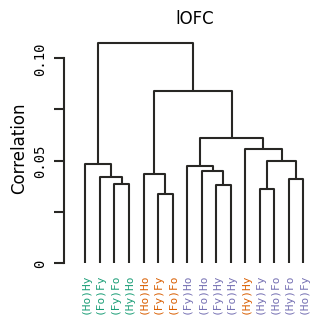

Silhouette Score:  0.44156253324204287


In [2]:
#lofc
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
BLACK = "#282724"
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['lofc']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

all_subjects_rdm = np.zeros((len(subject_inds), 4, 16, 16))
average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))

for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
            subject_average_matrices = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices.npy')

            average_all_subjects_rdm[i] = subject_average_matrices


    average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)

    Z = linkage(average_rdm, method='average')

    # 绘制树状图
    from matplotlib import cm
    import matplotlib as mpl

    # 设置默认的颜色循环为黑色
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=BLACK)
    plt.figure(figsize=(3, 3))
    #plt.title('Hierarchical Clustering Dendrogram', fontsize=12)
    #plt.xlabel('Condition')
    plt.ylabel('Correlation', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    dendrogram(
        Z,
        orientation='top',
        leaf_rotation=90.,
        leaf_font_size=8.,
        labels=categories.tolist(),
       # distance_sort='descending',

    )
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    #plt.gca().spines['left'].set_visible(False)
    ax = plt.gca()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_bounds(0, 0.10)  # 设置左边框的刻度范围
    ax.spines["left"].set_color(BLACK)
    
    ax.set_yticks([0, 0.025, 0.05, 0.075, 0.10])
    ax.set_yticklabels(['0', '', '0.05', '', '0.10'])
    # 设置y轴刻度标签的旋转角度和字体大小
    for label in ax.get_ymajorticklabels():
        label.set_rotation(90)
        label.set_fontsize(10)
        label.set_verticalalignment('center')
    # 设置刻度线样式
    ax.tick_params(axis='y', direction='out', length=7, width=1.5, pad=5,color = BLACK)
    ax.tick_params(axis='x', bottom=False)
    plt.title('lOFC', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    # 绘制刻度线

    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
            
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.png", dpi=300, format="png", bbox_inches='tight')


    plt.show()
    # 恢复默认的颜色循环
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    from scipy.cluster.hierarchy import fcluster
    from sklearn.metrics import silhouette_score
    k = 2
    labels = fcluster(Z, k, criterion='maxclust')

    # 计算轮廓系数
    score = silhouette_score(average_rdm, labels, metric='correlation')

    print('Silhouette Score: ', score)



  0%|          | 0/1 [00:00<?, ?it/s]

Working on hp 


  0%|          | 0/27 [00:00<?, ?it/s]

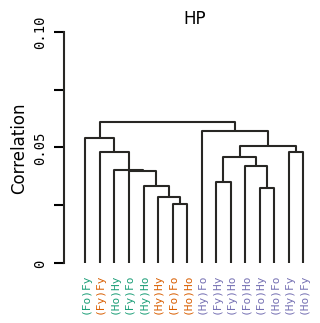

Silhouette Score:  0.4339875562633002


In [3]:
#hp
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
BLACK = "#282724"
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['hp']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

all_subjects_rdm = np.zeros((len(subject_inds), 4, 16, 16))
average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))

for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
            subject_average_matrices = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices.npy')

            average_all_subjects_rdm[i] = subject_average_matrices


    average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)

    Z = linkage(average_rdm, method='average')

    # 绘制树状图
    from matplotlib import cm
    import matplotlib as mpl

    # 设置默认的颜色循环为黑色
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=BLACK)
    plt.figure(figsize=(3, 3))
    #plt.title('Hierarchical Clustering Dendrogram', fontsize=12)
    #plt.xlabel('Condition')
    plt.ylabel('Correlation', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    dendrogram(
        Z,
        orientation='top',
        leaf_rotation=90.,
        leaf_font_size=8.,
        labels=categories.tolist(),
       # distance_sort='descending',

    )
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    #plt.gca().spines['left'].set_visible(False)
    ax = plt.gca()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_bounds(0, 0.10)  # 设置左边框的刻度范围
    ax.spines["left"].set_color(BLACK)
    
    ax.set_yticks([0, 0.025, 0.05, 0.075, 0.10])
    ax.set_yticklabels(['0', '', '0.05', '', '0.10'])
    # 设置y轴刻度标签的旋转角度和字体大小
    for label in ax.get_ymajorticklabels():
        label.set_rotation(90)
        label.set_fontsize(10)
        label.set_verticalalignment('center')
    # 设置刻度线样式
    ax.tick_params(axis='y', direction='out', length=7, width=1.5, pad=5)
    ax.tick_params(axis='x', bottom=False)
    plt.title('HP', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    # 绘制刻度线

    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
            
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.png", dpi=300, format="png", bbox_inches='tight')


    plt.show()
    # 恢复默认的颜色循环
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    from scipy.cluster.hierarchy import fcluster
    from sklearn.metrics import silhouette_score
    k = 2
    labels = fcluster(Z, k, criterion='maxclust')

    # 计算轮廓系数
    score = silhouette_score(average_rdm, labels, metric='correlation')

    print('Silhouette Score: ', score)



  0%|          | 0/1 [00:00<?, ?it/s]

Working on dlPFC 


  0%|          | 0/27 [00:00<?, ?it/s]

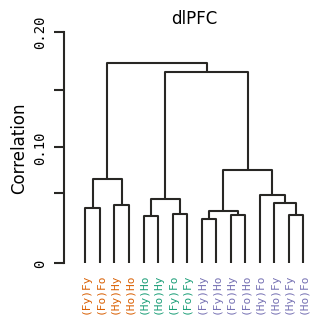

Silhouette Score:  0.48286012998118355


In [3]:
#dlPFC
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
BLACK = "#282724"
GREY_DARK = "#747473"
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['dlPFC']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

all_subjects_rdm = np.zeros((len(subject_inds), 4, 16, 16))
average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))

for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
            subject_average_matrices = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices.npy')

            average_all_subjects_rdm[i] = subject_average_matrices


    average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)

    Z = linkage(average_rdm, method='average')

    # 绘制树状图
    from matplotlib import cm
    import matplotlib as mpl

    # 设置默认的颜色循环为黑色
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=BLACK)
    plt.figure(figsize=(3, 3))
    #plt.title('Hierarchical Clustering Dendrogram', fontsize=12)
    #plt.xlabel('Condition')
    plt.ylabel('Correlation', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    dendrogram(
        Z,
        orientation='top',
        leaf_rotation=90.,
        leaf_font_size=8.,
        labels=categories.tolist(),
       # distance_sort='descending',

    )
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    #plt.gca().spines['left'].set_visible(False)
    ax = plt.gca()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_bounds(0, 0.20)  # 设置左边框的刻度范围
    ax.spines["left"].set_color(BLACK)
    
    ax.set_yticks([0, 0.060, 0.100, 0.150, 0.20])
    ax.set_yticklabels(['0', '', '0.10', '', '0.20'])
    # 设置y轴刻度标签的旋转角度和字体大小
    for label in ax.get_ymajorticklabels():
        label.set_rotation(90)
        label.set_fontsize(10)
        label.set_verticalalignment('center')
    # 设置刻度线样式
    ax.tick_params(axis='y', direction='out', length=7, width=1.5, pad=5,color=BLACK)
    ax.tick_params(axis='x', bottom=False)
    plt.title('dlPFC', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    # 绘制刻度线

    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
            
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.png", dpi=300, format="png", bbox_inches='tight')

    plt.show()
    # 恢复默认的颜色循环
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    from scipy.cluster.hierarchy import fcluster
    from sklearn.metrics import silhouette_score
    k = 2
    labels = fcluster(Z, k, criterion='maxclust')

    # 计算轮廓系数
    score = silhouette_score(average_rdm, labels, metric='correlation')

    print('Silhouette Score: ', score)



  0%|          | 0/1 [00:00<?, ?it/s]

Working on FFA-PPA 


  0%|          | 0/27 [00:00<?, ?it/s]

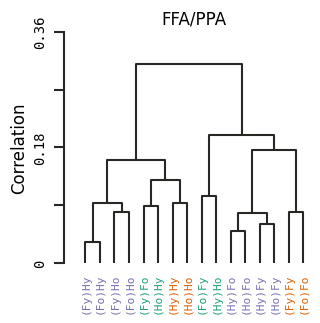

Silhouette Score:  0.7273229585413397


In [13]:
#FFA-PPA
from tqdm import tqdm_notebook
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import nibabel as nb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.pipeline import Pipeline
from nilearn.maskers import NiftiMasker
from nilearn import image
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns
BLACK = "#282724"
GREY_DARK = "#747473"
from matplotlib import rcParams
rcParams['font.family'] = 'monospace'
#svc =SVC(kernel='poly',class_weight='balanced')
mask_names = ['FFA-PPA']
subject_inds = [1,2,3,4,5,7,8,9,10,11,12,14,15,16,17,18,20,21,22,23,24,25,26,27,28,29,30]
categories = np.array(['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy', '(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho', '(Fy)Hy', '(Fy)Ho', '(Fo)Hy', '(Fo)Ho', '(Hy)Fy', '(Hy)Fo', '(Ho)Fy', '(Ho)Fo'])

all_subjects_rdm = np.zeros((len(subject_inds), 4, 16, 16))
average_all_subjects_rdm = np.zeros((len(subject_inds), 16, 16))

for mask_name in tqdm_notebook(mask_names):
    print("Working on %s " %(mask_name))
    for i, current_subject in enumerate(tqdm_notebook(subject_inds)): 
            subject_average_matrices = np.load(f'/home/garlicseed/Mount/final/RSA/rdm_matrix/{mask_name}/sub-{current_subject:02}_{mask_name}_matrices.npy')

            average_all_subjects_rdm[i] = subject_average_matrices


    average_rdm = np.nanmean(average_all_subjects_rdm, axis=0)

    Z = linkage(average_rdm, method='average')

    # 绘制树状图
    from matplotlib import cm
    import matplotlib as mpl

    # 设置默认的颜色循环为黑色
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=BLACK)
    plt.figure(figsize=(3, 3))
    #plt.title('Hierarchical Clustering Dendrogram', fontsize=12)
    #plt.xlabel('Condition')
    plt.ylabel('Correlation', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    dendrogram(
        Z,
        orientation='top',
        leaf_rotation=90.,
        leaf_font_size=8.,
        labels=categories.tolist(),
       # distance_sort='descending',

    )
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    #plt.gca().spines['left'].set_visible(False)
    ax = plt.gca()
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_bounds(0, 0.36)  # 设置左边框的刻度范围
    ax.spines["left"].set_color(BLACK)
    
    ax.set_yticks([0, 0.090, 0.180, 0.270, 0.36])
    ax.set_yticklabels(['0', '', '0.18', '', '0.36'])
    # 设置y轴刻度标签的旋转角度和字体大小
    for label in ax.get_ymajorticklabels():
        label.set_rotation(90)
        label.set_fontsize(10)
        label.set_verticalalignment('center')
    # 设置刻度线样式
    ax.tick_params(axis='y', direction='out', length=7, width=1.5, pad=5,color=BLACK)
    ax.tick_params(axis='x', bottom=False)
    plt.title('FFA/PPA', fontsize=12, fontdict={'family': 'DejaVu Sans'})
    # 绘制刻度线

    labels = ax.get_xmajorticklabels()
    for label in labels:
        text = label.get_text()
        if text in ['(Fy)Fo', '(Fo)Fy', '(Hy)Ho', '(Ho)Hy']:
            label.set_color('#1B9E77')
        elif text in ['(Fy)Fy', '(Fo)Fo', '(Hy)Hy', '(Ho)Ho']:
            label.set_color('#D95F02')
        else:
            label.set_color('#7570B3')
            
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.svg", dpi=300, format="svg", bbox_inches='tight')
    plt.savefig(f"/media/garlicseed/data/final/RSA/hierarchical_cluster_analysis/Figures/{mask_name}_figure.png", dpi=300, format="png", bbox_inches='tight')

    plt.show()
    # 恢复默认的颜色循环
    mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=['b', 'g', 'r', 'c', 'm', 'y', 'k'])
    from scipy.cluster.hierarchy import fcluster
    from sklearn.metrics import silhouette_score
    k = 2
    labels = fcluster(Z, k, criterion='maxclust')

    # 计算轮廓系数
    score = silhouette_score(average_rdm, labels, metric='correlation')

    print('Silhouette Score: ', score)

